In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

celerity = 299792458
h_bar = 1.054571817e-34
a = 426e-9
e =  1.60217646e-19

In [29]:
# fre contains not centered with size
# fre2 is centered point source
# fre3: fcen = 0.25, df = 1.5, gaussian point source at (0.1234,0)
# fre4: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), Y sym phase=-1
# fre5: fcen = 0.25, df = 1.5, gaussian point source at (0,0.1234)
# fre6: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), no sym
# fre7: fcen = 0.25, df = 0.75, gaussian point source at (0.1234,0), (res:30), Y sym phase=1
# fre9: fcen = 0.225, df = 0.775, odd, (res:30)
# fre10: fcen = 0.225, df = 0.775, even, (res:30)

# 3D
# fre11: fcen = 0.225, df = 1.525, "odd", (res:20), (no pml oops)
# fre12: fcen = 0.225, df = 1.525, "odd", (res:20), pml layers
# fre13: fcen = 0.225, df = 1.525, "even", (res:20), pml layers
def energy_vs_k(series):
    lines_list = []
    lines_list_im = []
    with open("dot_dat_files/fre" + series + ".dat","r") as f:
        lines = f.readlines()
        for line in lines:
            line_list = list(map(float,line.split(", ")))
            lines_list.append(line_list)
    with open("dot_dat_files/fim" + series + ".dat","r") as f:
        lines = f.readlines()
        for line in lines:
            line_list = list(map(float,line.split(", ")))
            lines_list_im.append(line_list)
    
    k_points = [float(line[1]) for line in lines_list]

    max_len = max(len(line) for line in lines_list)
    for line in lines_list:
        if len(line) < max_len:
            line.extend([np.nan] * (max_len - len(line)))
    for line in lines_list_im:
        if len(line) < max_len:
            line.extend([np.nan] * (max_len - len(line)))

    # The columns of the following matrix represent the detected frequencies for each k value
    omegas_re = np.array(lines_list).T[4:]
    omegas_im = np.array(lines_list_im).T[4:]

    Q = omegas_re/(-2*omegas_im)

    energies = h_bar*omegas_re*2*np.pi*celerity/(a*e) # energies in eV instead of omega*a/2pi*c

    return k_points, list(energies), list(Q)

    

In [30]:
# Electron phase matching lines
v = 164352472.84818122
k = np.array([0,0.5])
electron_freq = v*k

electron_energy = electron_freq*h_bar/e*2*np.pi/a
electron_energy2 = [2*electron_energy[1], electron_energy[1]]

In [31]:
k_points, energies, Q = energy_vs_k("128even")
k_points, energies2, Q2 = energy_vs_k("128odd")

energies.extend(energies2)
Q.extend(Q2)

In [32]:
all_Q = np.concatenate(Q)
all_Q_no_nan = all_Q[~np.isnan(all_Q)]
min_Q = np.min(all_Q_no_nan)
max_Q = np.max(all_Q_no_nan)
print(min_Q, ",", max_Q)

-244210287.1066037 , 54737149.140092075


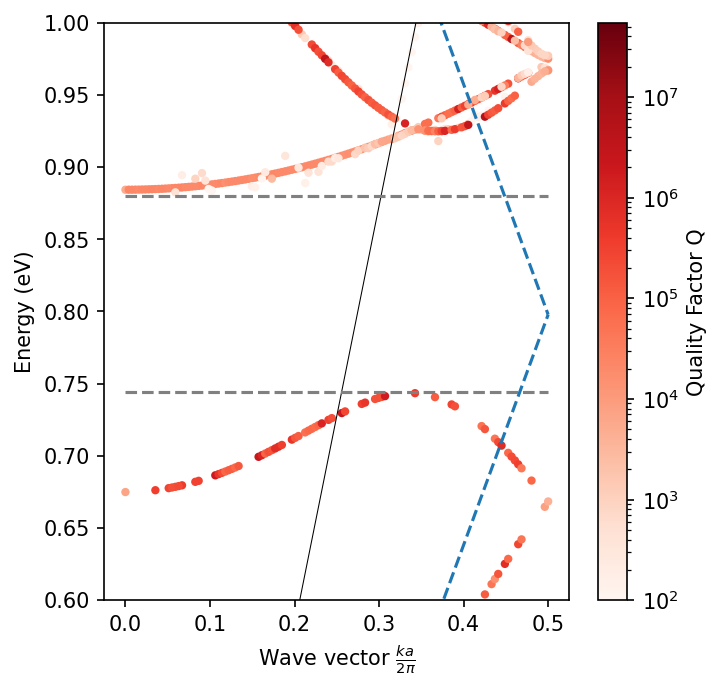

In [35]:


plt.figure(figsize=(5,5), dpi=150)

for n in range(len(energies)):
    sc = plt.scatter(k_points, energies[n], c=Q[n], cmap='Reds', norm=LogNorm(vmin=100,vmax=max_Q), marker='.')

# for n in range(len(energies2_35)):
#     sc = plt.scatter(k_points2_35, energies2_35[n], c=Q2_35[n], cmap='Reds', norm=LogNorm(), marker='.')
plt.plot(k, electron_energy, '--', c='tab:blue')
plt.plot(k, electron_energy2, '--')
plt.plot([0,0.5], [0,h_bar*0.5*2*np.pi*celerity/a/e], 'k', lw=0.5)
plt.plot([0,0.5], [0,h_bar*0.5/np.sqrt(11.68)*2*np.pi*celerity/a/e])
plt.hlines(y=[0.744,0.88], xmin=0, xmax=0.5, colors='grey', ls='--')
plt.ylabel(r'Energy (eV)')
plt.xlabel(r'Wave vector $\frac{ka}{2\pi}$')
plt.colorbar(sc, label='Quality Factor Q')
plt.ylim((0.6,1))
plt.show()